# Detectability score

### Combine all score from Copyleaks, Sapling, Zerogpt.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('../datasets.csv')
df.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...


In [3]:
df.shape

(180, 6)

# Copyleaks
- use the first number, i.e. AI Content Found (Percentage of text that may be AI-generated)
- the second number of AI phrases detected.

In [4]:
df_copyleaks = df.copy()
df_copyleaks['AI_detectability'] = 100
df_copyleaks['humanized_detectability'] = 0
df_copyleaks.head(6)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,0
1,1,1,gemini2.5pro,Grammarly,The integration of social media into the lives...,Social media has become a big part of young pe...,100,0
2,1,1,gemini2.5pro,HumanizeAI,The integration of social media into the lives...,The penetration of social media into the lives...,100,0
3,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,100,0
4,1,1,gemini2.5pro,UndetectableAI,The integration of social media into the lives...,Young people face a harmful environment throug...,100,0
5,1,1,gemini2.5pro,writehuman.ai,The integration of social media into the lives...,There is an important and critical psychologic...,100,0


In [5]:
df_copyleaks.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_copyleaks.head(6)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,0
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100,0
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,100,0
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100,0
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,100,0
5,1,3,gpt4.0,AIHumanizer,"In recent years, social media has revolutioniz...","Over the past few years, social media has comp...",100,0


In [6]:
#AIHumanizer
#set first 30 rows of 'humanized_detectability' to 100
df_copyleaks.loc[0:29, 'humanized_detectability'] = 100

In [7]:
#Grammarly
#set rows 30-59 of 'humanized_detectability' to 100
df_copyleaks.loc[30:59, 'humanized_detectability'] = 100

In [8]:
#HumanizeAI
HumanizeAI = [100, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 64.4, 100, 100, 100, 100, 73.1, 100, 100, 100, 0, 100, 100, 45.2]
#set rows 60-89 of 'humanized_detectability' to HumanizeAI list
df_copyleaks.loc[60:89, 'humanized_detectability'] = HumanizeAI

/var/folders/sl/36wj2dpn1fvgpr5ydrsxz8wm0000gn/T/ipykernel_30861/1315032471.py:4: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[100, 0, 0, 100, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 64.4, 100, 100, 100, 100, 73.1, 100, 100, 100, 0, 100, 100, 45.2]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_copyleaks.loc[60:89, 'humanized_detectability'] = HumanizeAI


In [9]:
#Quillbot
Quillbot = [100, 100, 80.3, 100, 100, 100, 100, 100, 0, 100, 0, 100 ,100 ,100 ,100 ,100 ,100 ,100, 0, 100,100, 100, 100, 100, 100, 100, 100, 100 ,100, 100]
#set rows 90-119 of 'humanized_detectability' to Quillbot list
df_copyleaks.loc[90:119, 'humanized_detectability'] = Quillbot

In [10]:
#UndetectableAI
UndetectableAI = [0, 0, 0, 0, 0, 0, 0, 0 ,0, 0, 0, 100, 100, 0, 0, 100, 0, 100, 0, 100, 100, 0, 0, 100, 100 ,100, 100, 100, 0, 100]
#set rows 120-149 of 'humanized_detectability' to UndetectableAI list
df_copyleaks.loc[120:149, 'humanized_detectability'] = UndetectableAI

In [11]:
#writehuman.ai
writehumanai = [0, 0, 62, 100, 0, 0, 0, 0, 0, 0, 0, 24.4, 0, 0, 0, 0, 0, 66.6, 0, 0, 78.8, 0, 0, 0, 0, 100, 0, 0, 100, 100]
#set rows 150-179 of 'humanized_detectability' to writehumanai list
df_copyleaks.loc[150:179, 'humanized_detectability'] = writehumanai
# set rows 176 of 'humanized_detectability' to NA
df_copyleaks.loc[176, 'humanized_detectability'] = None

# Zerogpt
- use fakePercentage (The Percentage of AI in your text)

In [12]:
zerogpt = pd.read_csv("zerogpt_results.csv")
print(zerogpt.shape)
zerogpt.head()

(210, 7)


,filepath,filename,fakePercentage,isHuman,feedback,aiWords,textWords
0,../datasets/essays/TOPIC3_2_GPT4.0.txt,TOPIC3_2_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,593,593
1,../datasets/essays/TOPIC4_2_GPT4.0.txt,TOPIC4_2_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,450,450
2,../datasets/essays/TOPIC1_1_GPT4.0.txt,TOPIC1_1_GPT4.0.txt,100.0,0.0,Your Text is AI/GPT Generated,258,258
3,../datasets/essays/TOPIC5_3_GEMINI2.5PRO.txt,TOPIC5_3_GEMINI2.5PRO.txt,100.0,0.0,Your Text is AI/GPT Generated,882,882
4,../datasets/essays/TOPIC2_1_GEMINI2.5PRO.txt,TOPIC2_1_GEMINI2.5PRO.txt,100.0,0.0,Your Text is AI/GPT Generated,276,276


In [13]:
zerogpt['type'] = None
zerogpt['topic'] = None
zerogpt['length'] = None
zerogpt['AI_model'] = None
for i, row in zerogpt.iterrows():
    type = row['filepath'].split('/')
    if len(type) == 4:
        zerogpt.at[i, 'type'] = 'AI'
    else:
        zerogpt.at[i, 'type'] = type[3]
    topic, length, model = row['filename'].split('_')
    topic = int(topic[5])
    length = int(length)
    model = model[:-4].lower()
    zerogpt.at[i, 'topic'] = topic
    zerogpt.at[i, 'length'] = length
    zerogpt.at[i, 'AI_model'] = model
zerogpt.sort_values(by=['type','topic','length', 'AI_model'], inplace=True, ignore_index=True)
zerogpt.head()

,filepath,filename,fakePercentage,isHuman,feedback,aiWords,textWords,type,topic,length,AI_model
0,../datasets/essays/TOPIC1_1_GEMINI2.5PRO.txt,TOPIC1_1_GEMINI2.5PRO.txt,100.00,0.0,Your Text is AI/GPT Generated,266,266,AI,1,1,gemini2.5pro
1,../datasets/essays/TOPIC1_1_GPT4.0.txt,TOPIC1_1_GPT4.0.txt,100.00,0.0,Your Text is AI/GPT Generated,258,258,AI,1,1,gpt4.0
2,../datasets/essays/TOPIC1_2_GEMINI2.5PRO.txt,TOPIC1_2_GEMINI2.5PRO.txt,79.21,12.5,Most of Your Text is AI/GPT Generated,476,578,AI,1,2,gemini2.5pro
3,../datasets/essays/TOPIC1_2_GPT4.0.txt,TOPIC1_2_GPT4.0.txt,100.00,0.0,Your Text is AI/GPT Generated,517,517,AI,1,2,gpt4.0
4,../datasets/essays/TOPIC1_3_GEMINI2.5PRO.txt,TOPIC1_3_GEMINI2.5PRO.txt,72.07,12.5,Most of Your Text is AI/GPT Generated,763,988,AI,1,3,gemini2.5pro


In [14]:
detect_score = zerogpt['fakePercentage'].tolist()
ai_score = detect_score[:30]
ai_score = ai_score*6
len(ai_score)

180

In [15]:
humanized_score = detect_score[30:]
len(humanized_score)

180

In [16]:
df_zerogpt = df.copy()
df_zerogpt.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_zerogpt['AI_detectability'] = ai_score
df_zerogpt['humanized_detectability'] = humanized_score
df_zerogpt.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100.00,100.00
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100.00,100.00
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,79.21,100.00
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100.00,100.00
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,72.07,92.24


# Sapling
- use 'score' column (from 0 to 1, with 0 indicating the maximum confidence that the text is human-written, and 1 indicating the maximum confidence that the text is AI-generated.)

In [17]:
sapling = pd.read_csv('sapling_results.csv')
print(sapling.shape)
sapling.head()

(210, 6)


,filepath,filename,score,sentence_score,token_probs,token
0,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC3_2_GPT4.0.txt,0.999960,"[{""score"": 0.9931961718574452, ""sentence"": ""J....","[0.9999520873934671, 0.9999339143323596, 0.999...","[""J"", ""."", ""K"", ""."", "" Rowling"", ""\u2019"", ""s""..."
1,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC4_2_GPT4.0.txt,0.996421,"[{""score"": 0.04109587792356928, ""sentence"": ""A...","[0.9999875543207963, 0.9999881878793531, 0.999...","[""As"", "" artificial"", "" intelligence"", "" ("", ""..."
2,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GPT4.0.txt,0.999856,"[{""score"": 0.9970659579067691, ""sentence"": ""So...","[0.9999877169693718, 0.9999878612616158, 0.999...","[""Social"", "" media"", "" has"", "" undeniably"", "" ..."
3,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC5_3_GEMINI2.5PRO.txt,0.999942,"[{""score"": 3.702376560887899e-08, ""sentence"": ...","[0.9999844959274924, 0.9999861980550122, 0.999...","[""The"", "" landscape"", "" of"", "" childhood"", "" i..."
4,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC2_1_GEMINI2.5PRO.txt,0.999974,"[{""score"": 0.00016756883622148777, ""sentence"":...","[0.9999881489402469, 0.9999884189392105, 0.999...","[""A"", "" silent"", "","", "" stationary"", "" fan"", ""..."


In [18]:
humanizers = ['AIHumanizer', 'Grammarly', 'HumanizeAI', 'Quillbot', 'UndetectableAI', 'writehuman.ai']
sapling['type'] = None
sapling['topic'] = None
sapling['length'] = None
sapling['AI_model'] = None
for i, row in sapling.iterrows():
    type = row['filepath'].split('/')
    isai = True
    for humanizer in humanizers:
        if humanizer in type:
            sapling.at[i, 'type'] = humanizer
            isai = False
            break
    if isai:
        sapling.at[i, 'type'] = 'AI'
    topic, length, model = row['filename'].split('_')
    topic = int(topic[5])
    length = int(length)
    model = model[:-4].lower()
    sapling.at[i, 'topic'] = topic
    sapling.at[i, 'length'] = length
    sapling.at[i, 'AI_model'] = model
sapling.sort_values(by=['type','topic','length', 'AI_model'], inplace=True, ignore_index=True)
sapling.head()

,filepath,filename,score,sentence_score,token_probs,token,type,topic,length,AI_model
0,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GEMINI2.5PRO.txt,0.999977,"[{""score"": 0.1356348630967481, ""sentence"": ""Th...","[0.9999855877567825, 0.9999863500279389, 0.999...","[""The"", "" integration"", "" of"", "" social"", "" me...",AI,1,1,gemini2.5pro
1,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_1_GPT4.0.txt,0.999856,"[{""score"": 0.9970659579067691, ""sentence"": ""So...","[0.9999877169693718, 0.9999878612616158, 0.999...","[""Social"", "" media"", "" has"", "" undeniably"", "" ...",AI,1,1,gpt4.0
2,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_2_GEMINI2.5PRO.txt,0.999803,"[{""score"": 0.9912204637289971, ""sentence"": ""Th...","[0.9999881291587371, 0.9999884908911554, 0.999...","[""The"", "" pervasive"", "" integration"", "" of"", ""...",AI,1,2,gemini2.5pro
3,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_2_GPT4.0.txt,0.999874,"[{""score"": 0.9995484959432652, ""sentence"": ""In...","[0.9999889039127083, 0.999989114168784, 0.9999...","[""In"", "" the"", "" digital"", "" age"", "","", "" soci...",AI,1,2,gpt4.0
4,/Users/elizalesmana/Documents/GitHub/FYP/api/....,TOPIC1_3_GEMINI2.5PRO.txt,0.795353,"[{""score"": 0.9955431358518562, ""sentence"": ""Th...","[0.9999795212552272, 0.9999799321012688, 0.999...","[""The"", "" integration"", "" of"", "" social"", "" me...",AI,1,3,gemini2.5pro


In [19]:
detect_score = sapling['score'].tolist()
ai_score = detect_score[:30]
ai_score = [i*100 for i in ai_score]
ai_score = ai_score*6
len(ai_score)

180

In [20]:
humanized_score = detect_score[30:]
humanized_score = [i*100 for i in humanized_score]

In [21]:
df_sapling = df.copy()
df_sapling.sort_values(by=['humanizer','topic','length'], inplace=True, ignore_index=True)
df_sapling['AI_detectability'] = ai_score
df_sapling['humanized_detectability'] = humanized_score
df_sapling.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,AI_detectability,humanized_detectability
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",99.987373,99.995690
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,79.535308,99.990372


# Combine all three dataframes

In [22]:
df_merged = df_copyleaks.merge(df_zerogpt, on=['humanizer', 'topic', 'length', 'AI_model', 'AI_essay', 'humanized_essay'], suffixes=('_copyleaks', '_zerogpt'))
df_merged = df_merged.merge(df_sapling, on=['humanizer', 'topic', 'length', 'AI_model', 'AI_essay', 'humanized_essay'])
df_merged.rename(columns={'AI_detectability': 'sapling_AI', 'humanized_detectability': 'sapling_humanized', 'AI_detectability_copyleaks': 'copyleaks_AI', 'humanized_detectability_copyleaks': 'copyleaks_humanized', 'AI_detectability_zerogpt': 'zerogpt_AI', 'humanized_detectability_zerogpt': 'zerogpt_humanized'}, inplace=True)
df_merged.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100,100.0,100.00,100.00,99.997658,99.995351
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100,100.0,100.00,100.00,99.985579,99.961515
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,100,100.0,79.21,100.00,99.980250,98.531897
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100,100.0,100.00,100.00,99.987373,99.995690
4,1,3,gemini2.5pro,AIHumanizer,The integration of social media into the daily...,Social media has become such a regular part of...,100,100.0,72.07,92.24,79.535308,99.990372


In [23]:
# convert detectability columns to float
df_merged['copyleaks_AI'] = df_merged['copyleaks_AI'].astype('float64')
df_merged['copyleaks_humanized'] = df_merged['copyleaks_humanized'].astype('float64')
df_merged['zerogpt_AI'] = df_merged['zerogpt_AI'].astype('float64')
df_merged['zerogpt_humanized'] = df_merged['zerogpt_humanized'].astype('float64')
df_merged['sapling_AI'] = df_merged['sapling_AI'].astype('float64')
df_merged['sapling_humanized'] = df_merged['sapling_humanized'].astype('float64')

In [24]:
df_merged_temp = df_merged.drop(columns=['AI_essay', 'humanized_essay'])
df_merged_temp.to_csv('detection_results.csv', index=False)

# Analysis

#### mean of each humanizer and detectors (overall, by length, by AI model)

In [25]:
# group by humanizers and find mean of each detectability column
df_humanizer = df_merged.groupby('humanizer').mean(numeric_only=True)
# drop topic and length columns
df_humanizer = df_humanizer.drop(columns=['topic', 'length'])
df_humanizer.reset_index(inplace=True)
df_humanizer

,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,AIHumanizer,100.0,100.000000,98.175,99.390333,99.25927,99.917411
1,Grammarly,100.0,100.000000,98.175,98.736667,99.25927,99.625696
2,HumanizeAI,100.0,42.756667,98.175,23.680333,99.25927,70.250907
3,Quillbot,100.0,89.343333,98.175,84.378667,99.25927,91.023671
4,UndetectableAI,100.0,40.000000,98.175,13.993333,99.25927,90.175996
5,writehuman.ai,100.0,21.786207,98.175,32.848667,99.25927,83.910862


In [26]:
df_ai_humanizer = df_merged.groupby(['AI_model', 'humanizer']).mean(numeric_only=True)
df_ai_humanizer = df_ai_humanizer.drop(columns=['topic', 'length'])
df_ai_humanizer.reset_index(inplace=True)
df_ai_humanizer

,AI_model,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
0,gemini2.5pro,AIHumanizer,100.0,100.000000,96.495333,99.107333,98.559336,99.854567
1,gemini2.5pro,Grammarly,100.0,100.000000,96.495333,97.774667,98.559336,99.931092
2,gemini2.5pro,HumanizeAI,100.0,38.206667,96.495333,18.714667,98.559336,59.867368
3,gemini2.5pro,Quillbot,100.0,78.686667,96.495333,74.595333,98.559336,84.440737
4,gemini2.5pro,UndetectableAI,100.0,26.666667,96.495333,13.644667,98.559336,85.913429
5,gemini2.5pro,writehuman.ai,100.0,17.200000,96.495333,24.774000,98.559336,80.007925
6,gpt4.0,AIHumanizer,100.0,100.000000,99.854667,99.673333,99.959203,99.980255
7,gpt4.0,Grammarly,100.0,100.000000,99.854667,99.698667,99.959203,99.320300
8,gpt4.0,HumanizeAI,100.0,47.306667,99.854667,28.646000,99.959203,80.634447
9,gpt4.0,Quillbot,100.0,100.000000,99.854667,94.162000,99.959203,97.606606


# Visualization

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv('detection_results.csv')
df[(df['humanizer'] == 'writehuman.ai') & (df['topic'] == 5) & (df['length'] == 2) & (df['AI_model'] == 'gemini2.5pro')]

,topic,length,AI_model,humanizer,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
176,5,2,gemini2.5pro,writehuman.ai,100.0,NaN,100.0,0.0,99.746837,99.987541


In [29]:
df = df.drop(index=176)

In [30]:
# Melt the dataframe to make it suitable for Seaborn plotting
humanized_cols = ['copyleaks_humanized', 'zerogpt_humanized', 'sapling_humanized']
melted_df = df.melt(id_vars=['topic', 'length', 'AI_model', 'humanizer'],
                   value_vars=humanized_cols,
                   var_name='Detector',
                   value_name='AI_Score')
melted_df['Detector'] = melted_df['Detector'].str.replace('_humanized', '').str.capitalize()
melted_df

,topic,length,AI_model,humanizer,Detector,AI_Score
0,1,1,gemini2.5pro,AIHumanizer,Copyleaks,100.000000
1,1,1,gpt4.0,AIHumanizer,Copyleaks,100.000000
2,1,2,gemini2.5pro,AIHumanizer,Copyleaks,100.000000
3,1,2,gpt4.0,AIHumanizer,Copyleaks,100.000000
4,1,3,gemini2.5pro,AIHumanizer,Copyleaks,100.000000
...,...,...,...,...,...,...
532,5,1,gemini2.5pro,writehuman.ai,Sapling,99.883341
533,5,1,gpt4.0,writehuman.ai,Sapling,99.993364
534,5,2,gpt4.0,writehuman.ai,Sapling,99.929675
535,5,3,gemini2.5pro,writehuman.ai,Sapling,90.635068


In [31]:
# custom_palette = sns.color_palette(['#a8bccb', '#5e7c93', '#293742'])
# custom_palette = sns.color_palette(['#00458d', '#04924d', '#593ea1'])
custom_palette = sns.color_palette(["#c6e9f9", "#b6f0d5", "#fae7bf"])
sns.set_palette(custom_palette)

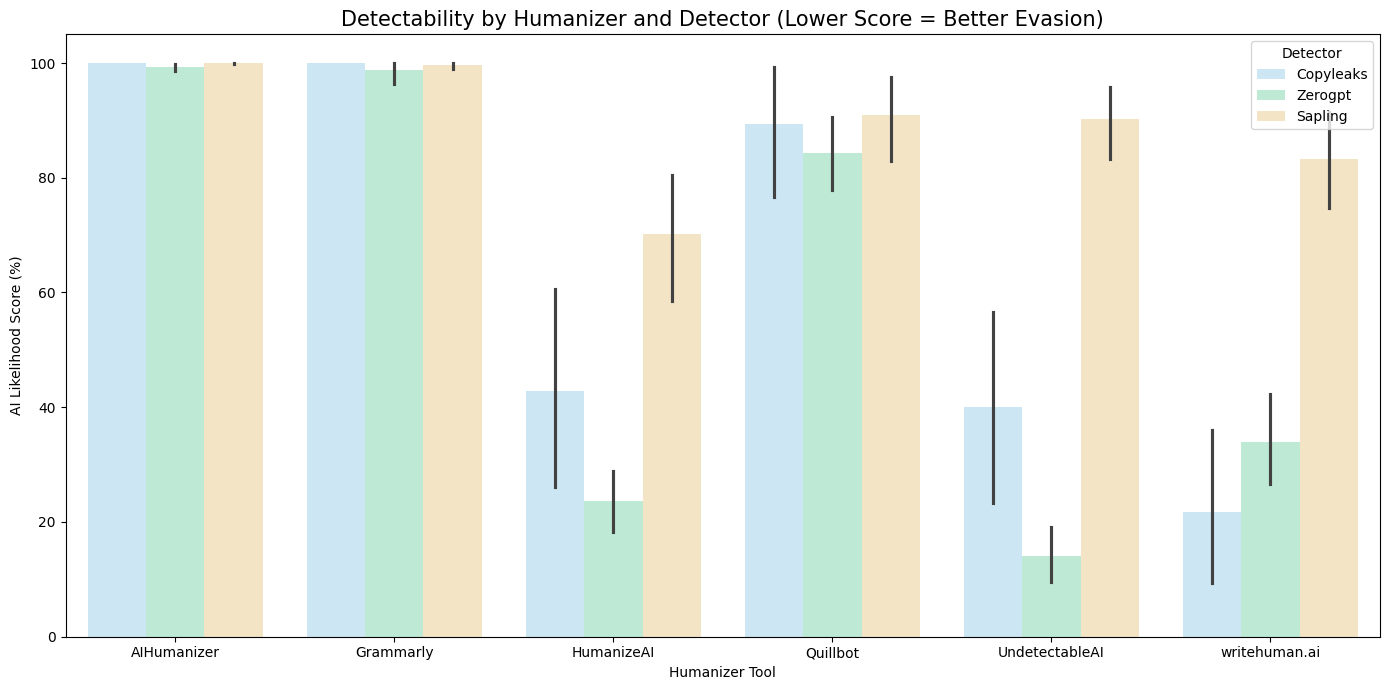

In [32]:
plt.rcParams['figure.figsize'] = (14, 7)

# --- Visualization 1: Performance across different Detectors ---
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='Detector')
plt.title('Detectability by Humanizer and Detector (Lower Score = Better Evasion)', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.legend(title='Detector', loc='upper right')
plt.tight_layout()
plt.show()

/var/folders/sl/36wj2dpn1fvgpr5ydrsxz8wm0000gn/T/ipykernel_30861/9387155.py:3: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='AI_model', palette=custom_palette)


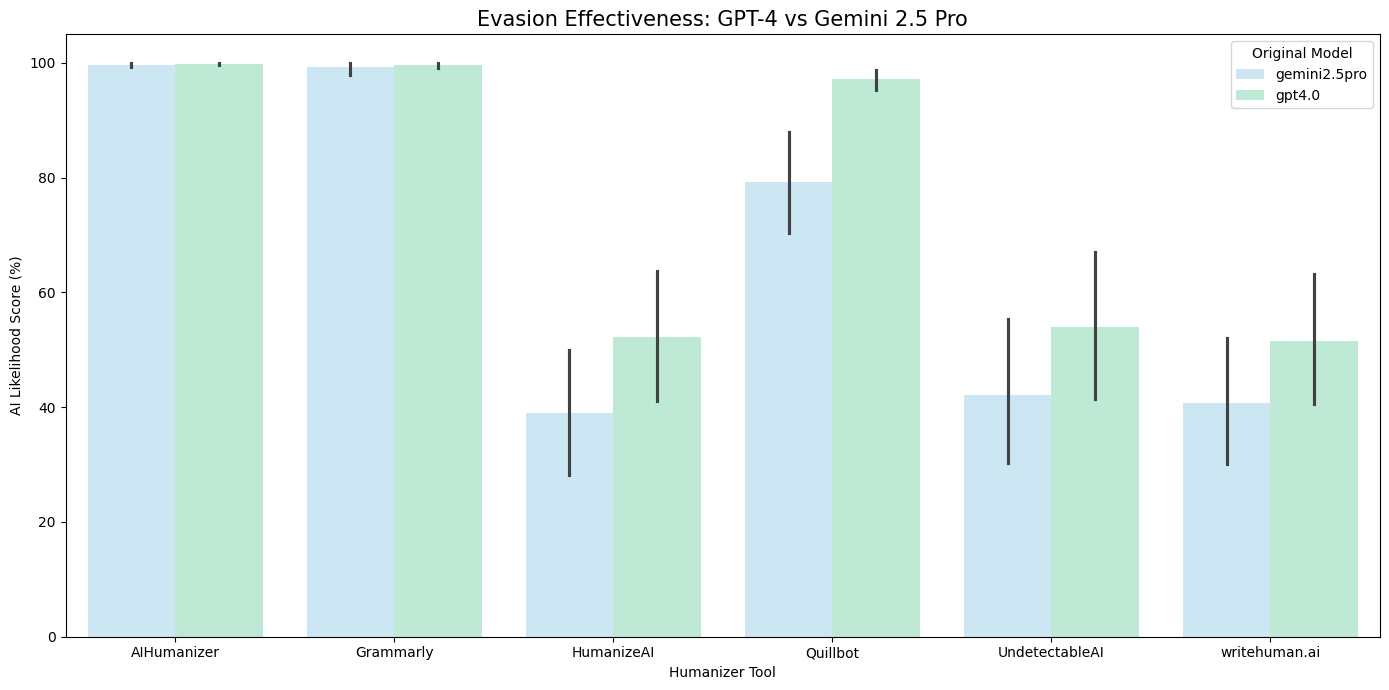

In [33]:
# --- Visualization 2: Impact of the Original AI Model ---
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='AI_model', palette=custom_palette)
plt.title('Evasion Effectiveness: GPT-4 vs Gemini 2.5 Pro', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.legend(title='Original Model', loc='upper right')
plt.tight_layout()
plt.show()

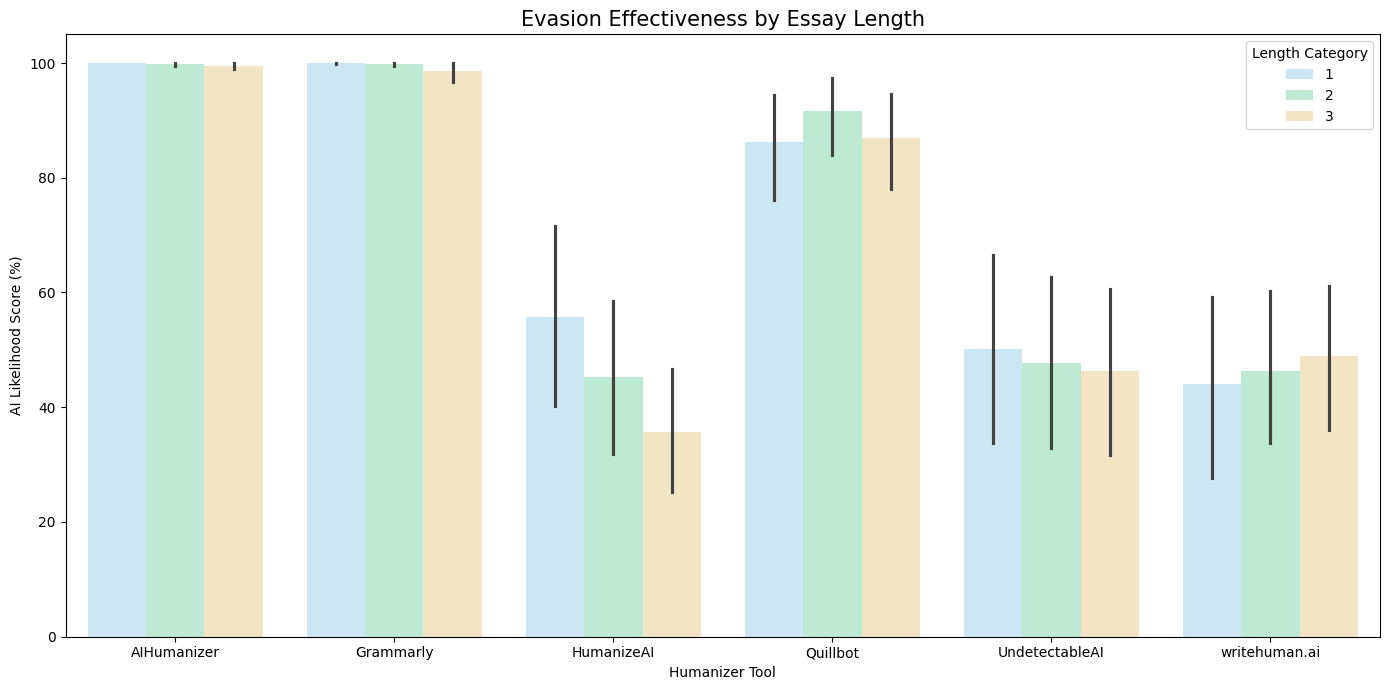

In [34]:
# --- Visualization 3: Impact of Essay Length ---
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='length', palette=custom_palette)
plt.title('Evasion Effectiveness by Essay Length', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.legend(title='Length Category', loc='upper right')
plt.tight_layout()
plt.show()

/var/folders/sl/36wj2dpn1fvgpr5ydrsxz8wm0000gn/T/ipykernel_30861/4057933446.py:3: UserWarning: 
The palette list has fewer values (3) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='topic', palette=custom_palette)


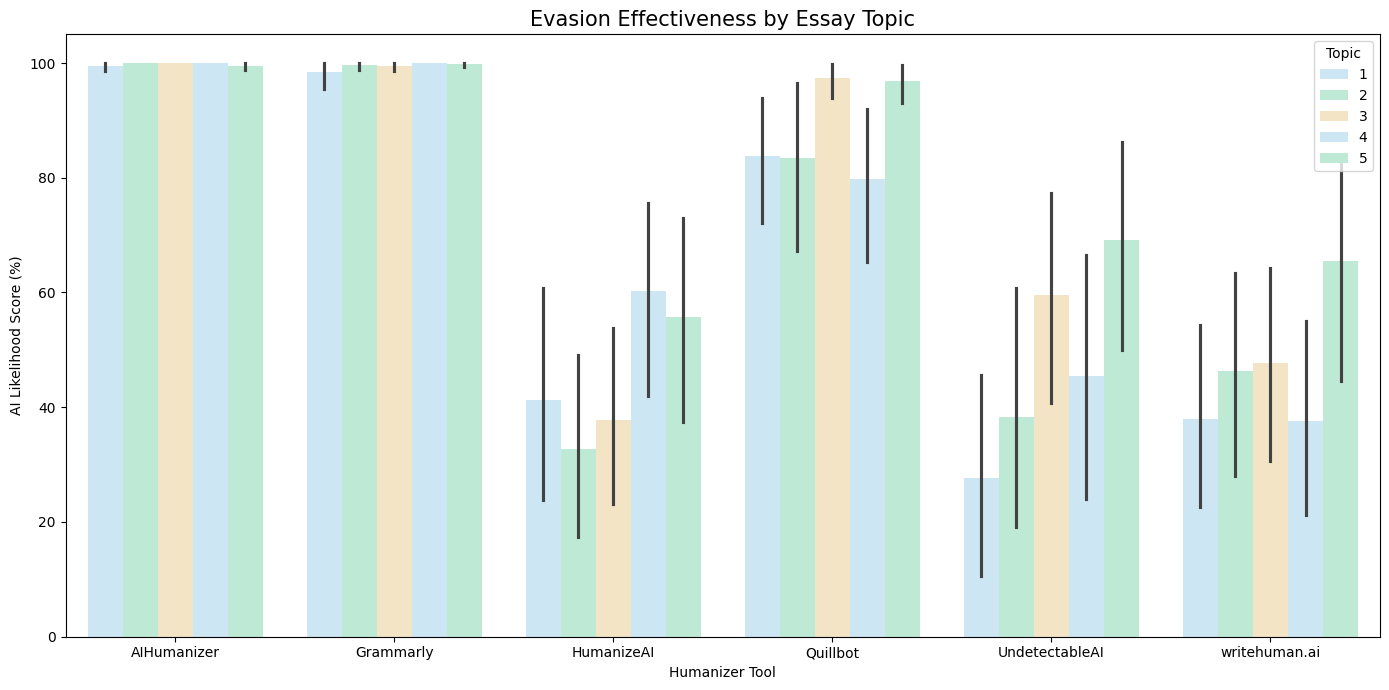

In [35]:
# --- Visualization 4: Impact of Topic ---
plt.figure()
sns.barplot(data=melted_df, x='humanizer', y='AI_Score', hue='topic', palette=custom_palette)
plt.title('Evasion Effectiveness by Essay Topic', fontsize=15)
plt.ylabel('AI Likelihood Score (%)')
plt.xlabel('Humanizer Tool')
plt.legend(title='Topic', loc='upper right')
plt.tight_layout()
plt.show()

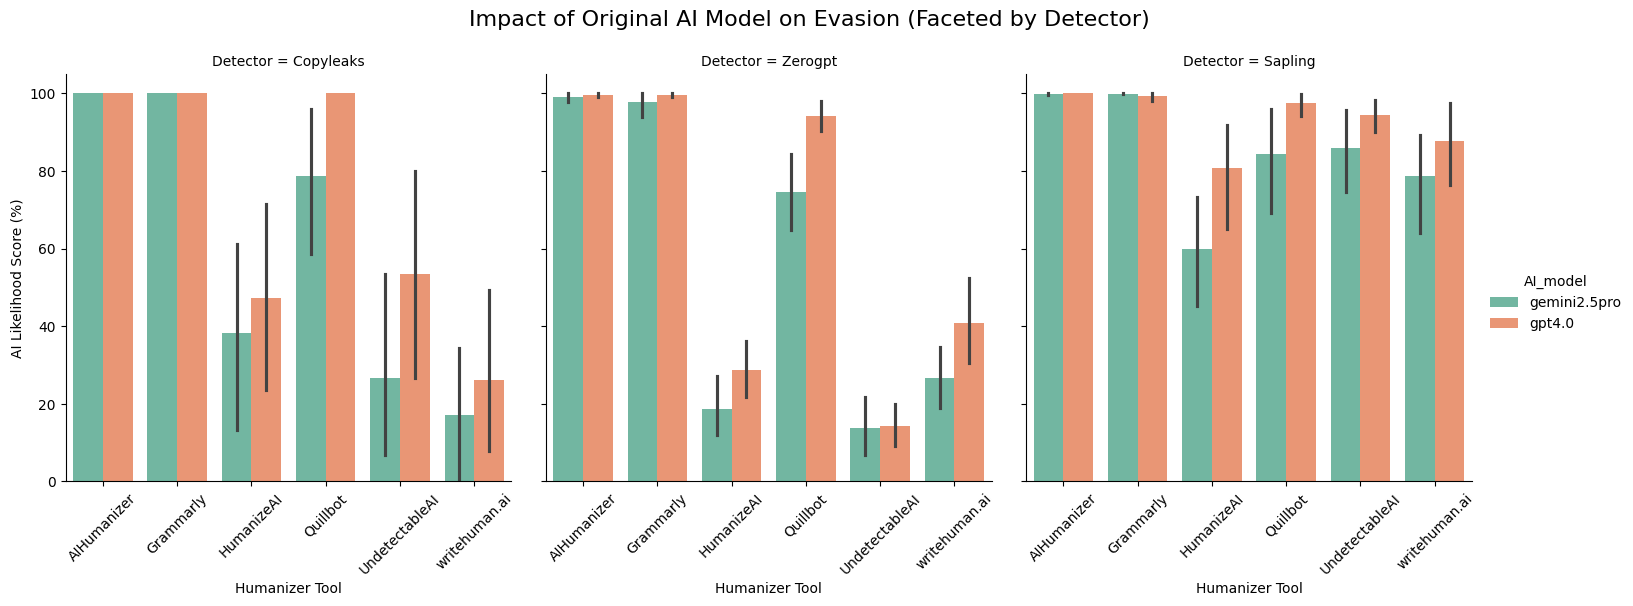

In [36]:
# AI model for each detectors
g2 = sns.catplot(
    data=melted_df, x='humanizer', y='AI_Score', hue='AI_model', 
    col='Detector', kind='bar', palette='Set2', height=5, aspect=1
)
g2.set_xticklabels(rotation=45)
g2.set_axis_labels("Humanizer Tool", "AI Likelihood Score (%)")
g2.fig.suptitle('Impact of Original AI Model on Evasion (Faceted by Detector)', y=1.06, fontsize=16)
plt.show()

In [47]:
# filtered out AIHumanizer and Grammarly
df_filtered = df[~df['humanizer'].isin(['AIHumanizer', 'Grammarly'])]
df_filtered.shape

(119, 10)

In [48]:
# model it as two-way ANOVA with humanizer and AI_model as main effects to check if AI_model has a significant effect on detectability scores for each detector
# 1. Copyleaks
import scipy.stats as stats
anova_data_copyleaks = [df_filtered[df_filtered['humanizer'] == humanizer]['copyleaks_humanized'] for humanizer in df_filtered['humanizer'].unique()]
# two-way ANOVA
from statsmodels.formula.api import ols
import statsmodels.api as sm
df_copyleaks_anova = df_filtered[['humanizer', 'AI_model', 'copyleaks_humanized']].dropna()
model_copyleaks = ols('copyleaks_humanized ~ C(humanizer) + C(AI_model) + C(humanizer):C(AI_model)', data=df_copyleaks_anova).fit()
anova_copyleaks = sm.stats.anova_lm(model_copyleaks, typ=2)
print("Two-way ANOVA for Copyleaks:")
print(anova_copyleaks)
# p-value of interaction is higher than 0.05, so there is no interaction effect.
# For main effects, humanizer has a significant effect (p < 0.05) same as AI_model (p > 0.05) on copyleaks_humanized scores.

Two-way ANOVA for Copyleaks:
                                 sum_sq     df          F        PR(>F)
C(humanizer)               74334.061495    3.0  13.956942  8.741314e-08
C(AI_model)                 8149.120384    1.0   4.590230  3.433970e-02
C(humanizer):C(AI_model)    1781.525432    3.0   0.334499  8.004131e-01
Residual                  197060.376000  111.0        NaN           NaN


In [49]:
# no interaction effect, so we test for main effects 
model_copyleaks = ols('copyleaks_humanized ~ C(humanizer) + C(AI_model)', data=df_copyleaks_anova).fit()
anova_copyleaks = sm.stats.anova_lm(model_copyleaks, typ=2)
print("Two-way ANOVA for Copyleaks (Main Effects Only):")
print(anova_copyleaks)

Two-way ANOVA for Copyleaks (Main Effects Only):
                     sum_sq     df          F        PR(>F)
C(humanizer)   74334.061495    3.0  14.205730  6.280983e-08
C(AI_model)     8149.120384    1.0   4.672052  3.274845e-02
Residual      198841.901432  114.0        NaN           NaN


In [50]:
# 2. Zerogpt
df_zerogpt_anova = df_filtered[['humanizer', 'AI_model', 'zerogpt_humanized']].dropna()
model_zerogpt = ols('zerogpt_humanized ~ C(humanizer) + C(AI_model) + C(humanizer):C(AI_model)', data=df_zerogpt_anova).fit()
anova_zerogpt = sm.stats.anova_lm(model_zerogpt, typ=2)
print("Two-way ANOVA for Zerogpt:")
print(anova_zerogpt)

Two-way ANOVA for Zerogpt:
                                sum_sq     df           F        PR(>F)
C(humanizer)              88364.498587    3.0  114.711245  7.190454e-34
C(AI_model)                3674.765615    1.0   14.311300  2.514664e-04
C(humanizer):C(AI_model)   1437.379825    3.0    1.865949  1.394980e-01
Residual                  28501.882615  111.0         NaN           NaN


In [51]:
# no interaction effect, so we test for main effects
model_zerogpt = ols('zerogpt_humanized ~ C(humanizer) + C(AI_model)', data=df_zerogpt_anova).fit()
anova_zerogpt = sm.stats.anova_lm(model_zerogpt, type=2)
print("Two-way ANOVA for Zerogpt (Main Effects Only):")
print(anova_zerogpt)

Two-way ANOVA for Zerogpt (Main Effects Only):
                 df        sum_sq       mean_sq           F        PR(>F)
C(humanizer)    3.0  88307.573091  29435.857697  112.083181  7.376335e-34
C(AI_model)     1.0   3674.765615   3674.765615   13.992438  2.889203e-04
Residual      114.0  29939.262440    262.625109         NaN           NaN


In [52]:
# 3. Sapling
df_sapling_anova = df_filtered[['humanizer', 'AI_model', 'sapling_humanized']].dropna()
model_sapling = ols('sapling_humanized ~ C(humanizer) + C(AI_model) + C(humanizer):C(AI_model)', data=df_sapling_anova).fit()
anova_sapling = sm.stats.anova_lm(model_sapling, typ=2)
print("Two-way ANOVA for Sapling:")
print(anova_sapling)

Two-way ANOVA for Sapling:
                                sum_sq     df         F    PR(>F)
C(humanizer)               8302.605253    3.0  5.416587  0.001629
C(AI_model)                4991.442783    1.0  9.769193  0.002265
C(humanizer):C(AI_model)    705.543063    3.0  0.460294  0.710579
Residual                  56714.015951  111.0       NaN       NaN


In [53]:
# no interaction effect, so we test for main effects
model_zerogpt = ols('zerogpt_humanized ~ C(humanizer) + C(AI_model)', data=df_zerogpt_anova).fit()
anova_zerogpt = sm.stats.anova_lm(model_zerogpt, type=2)
print("Two-way ANOVA for Zerogpt (Main Effects Only):")
print(anova_zerogpt)

Two-way ANOVA for Zerogpt (Main Effects Only):
                 df        sum_sq       mean_sq           F        PR(>F)
C(humanizer)    3.0  88307.573091  29435.857697  112.083181  7.376335e-34
C(AI_model)     1.0   3674.765615   3674.765615   13.992438  2.889203e-04
Residual      114.0  29939.262440    262.625109         NaN           NaN


# More Analysis

In [118]:
df_merged[(df_merged['humanizer'] == 'writehuman.ai') & (df_merged['topic'] == 5) & (df_merged['length'] == 2) & (df_merged['AI_model'] == 'gemini2.5pro')]

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
176,5,2,gemini2.5pro,writehuman.ai,The landscape of childhood is often painted wi...,Your input was blocked due to inappropriate co...,100.0,NaN,100.0,0.0,99.746837,99.987541


In [119]:
df_merged = df_merged.drop(index=176)

In [132]:
df_merged.sort_values(by='sapling_humanized').head(10)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized,AI_essay_burstiness,humanized_essay_burstiness
151,1,1,gemini2.5pro,writehuman.ai,The integration of social media into the lives...,There is an important and critical psychologic...,100.0,0.0,100.00,0.00,99.997658,7.968067,6.249628,6.763690
86,5,2,gemini2.5pro,HumanizeAI,The landscape of childhood is often painted wi...,"A childhood is often set against the dazzling,...",100.0,0.0,100.00,17.62,99.746837,15.176588,7.951240,9.707051
109,4,1,gemini2.5pro,Quillbot,The rapid integration of artificial intelligen...,Artificial intelligence's quick assimilation i...,100.0,100.0,100.00,54.80,99.996099,16.915265,9.948478,8.304952
71,2,3,gemini2.5pro,HumanizeAI,The sudden silence of a broken fan on a hot da...,Jet-setting for a new fan is the first answer ...,100.0,0.0,99.99,3.33,99.996686,17.128860,6.633689,7.532646
89,5,3,gpt4.0,HumanizeAI,Childhood is often remembered through the lens...,Childhood is often remembered as a realm of si...,100.0,45.2,99.22,22.06,99.987774,20.562685,6.686647,8.488947
83,4,3,gpt4.0,HumanizeAI,As artificial intelligence (AI) continues to e...,With the rapidly evolving artificial intellige...,100.0,100.0,100.00,11.42,99.977061,25.317234,6.933085,8.970653
152,1,2,gpt4.0,writehuman.ai,"In the digital age, social media has become an...","In this era of digitization, especially for yo...",100.0,62.0,100.00,37.75,99.987373,28.267410,6.247755,6.569540
91,1,1,gemini2.5pro,Quillbot,The integration of social media into the lives...,Social media's introduction into young people'...,100.0,100.0,100.00,64.63,99.997658,30.721407,6.249628,7.323858
142,4,3,gemini2.5pro,UndetectableAI,Artificial intelligence is rapidly evolving fr...,Modern existence faces transformation through ...,100.0,0.0,100.00,0.00,99.988229,34.889657,10.339898,6.589074
82,4,3,gemini2.5pro,HumanizeAI,Artificial intelligence is rapidly evolving fr...,A very rapid pace of change has taken AI from ...,100.0,73.1,100.00,4.02,99.988229,38.008422,10.339898,10.834152


In [122]:
df_merged.sort_values(by=['sapling_humanized', 'zerogpt_humanized', 'copyleaks_humanized']).tail(6)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized
56,5,2,gemini2.5pro,Grammarly,The landscape of childhood is often painted wi...,The landscape of my childhood is vividly color...,100.0,100.0,100.0,100.00,99.746837,99.998182
96,2,1,gpt4.0,Quillbot,Fixing a broken fan may seem like a complicate...,Although fixing a broken fan might seem like a...,100.0,100.0,100.0,100.00,99.998450,99.998415
57,5,2,gpt4.0,Grammarly,"Growing up, few things held as much joy and ex...","During my childhood, few experiences brought a...",100.0,100.0,100.0,95.51,99.953983,99.998502
26,5,2,gpt4.0,AIHumanizer,"Growing up, few things held as much joy and ex...","When I think back to my childhood, nothing bro...",100.0,100.0,100.0,95.86,99.953983,99.998537
54,5,1,gemini2.5pro,Grammarly,"The unmistakable, frantic melody of its openin...","The unmistakable, frantic melody of the openin...",100.0,100.0,100.0,100.00,99.998630,99.998886
24,5,1,gemini2.5pro,AIHumanizer,"The unmistakable, frantic melody of its openin...","The lively, frantic tune of the opening theme ...",100.0,100.0,100.0,100.00,99.998630,99.998890


In [128]:
# calculate burstiness
import numpy as np
def burstiness(essay):
    sentences = essay.split('.')
    sentences = [s.strip() for s in sentences if s.strip()]
    sentences_length = [len(s.split()) for s in sentences]
    sd = np.std(sentences_length)
#    mean = np.mean(sentences_length)
    return sd

In [129]:
df_merged['AI_essay_burstiness'] = df_merged['AI_essay'].apply(burstiness)
df_merged['humanized_essay_burstiness'] = df_merged['humanized_essay'].apply(burstiness)

In [130]:
df_merged.head()

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized,AI_essay_burstiness,humanized_essay_burstiness
0,1,1,gemini2.5pro,AIHumanizer,The integration of social media into the lives...,The way social media has woven itself into the...,100.0,100.0,100.00,100.0,99.997658,99.995351,6.249628,7.107792
1,1,1,gpt4.0,AIHumanizer,Social media has undeniably transformed the wa...,Social media has really changed how young peop...,100.0,100.0,100.00,100.0,99.985579,99.961515,6.915380,6.546149
2,1,2,gemini2.5pro,AIHumanizer,The pervasive integration of social media into...,The way social media has woven itself into the...,100.0,100.0,79.21,100.0,99.980250,98.531897,7.862213,7.304858
3,1,2,gpt4.0,AIHumanizer,"In the digital age, social media has become an...","In today’s digital world, social media has rea...",100.0,100.0,100.00,100.0,99.987373,99.995690,6.247755,7.571584
4,1,3,gpt4.0,AIHumanizer,"In recent years, social media has revolutioniz...","Over the past few years, social media has comp...",100.0,100.0,99.99,100.0,99.990441,99.935826,5.720140,5.400926


/var/folders/sl/36wj2dpn1fvgpr5ydrsxz8wm0000gn/T/ipykernel_99554/2154824361.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df_merged, x='humanized_essay_burstiness', y='sapling_humanized' ,palette=custom_palette)


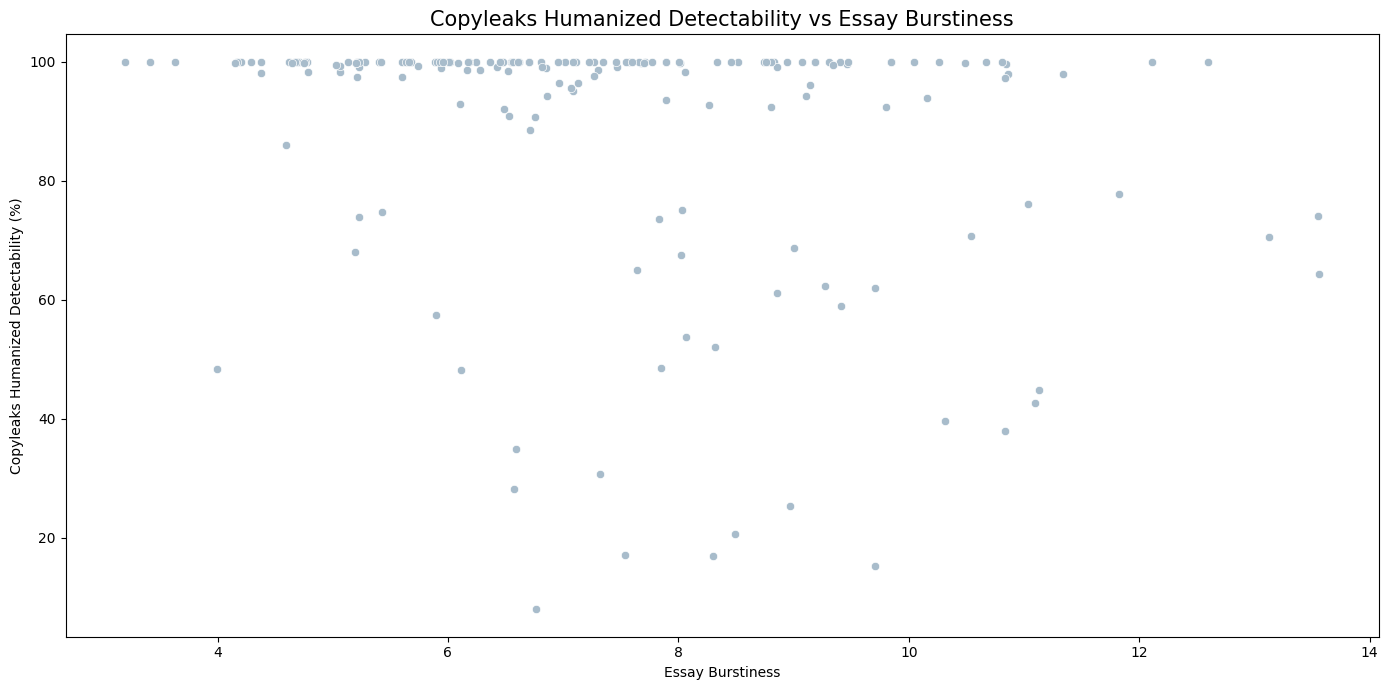

In [131]:
# find correlation between burstiness and detectability
# plot copyleaks_humanized vs humanized_essay_burstiness
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure()
sns.scatterplot(data=df_merged, x='humanized_essay_burstiness', y='sapling_humanized' ,palette=custom_palette)
plt.title('Copyleaks Humanized Detectability vs Essay Burstiness', fontsize=15)
plt.ylabel('Copyleaks Humanized Detectability (%)')
plt.xlabel('Essay Burstiness')
# plt.legend(title='Humanizer', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [135]:
df_merged['humanized_mean'] = df_merged[['copyleaks_humanized', 'zerogpt_humanized', 'sapling_humanized']].mean(axis=1)
df_merged.sort_values(by='humanized_mean').head(10)

,topic,length,AI_model,humanizer,AI_essay,humanized_essay,copyleaks_AI,copyleaks_humanized,zerogpt_AI,zerogpt_humanized,sapling_AI,sapling_humanized,AI_essay_burstiness,humanized_essay_burstiness,humanized_mean
151,1,1,gemini2.5pro,writehuman.ai,The integration of social media into the lives...,There is an important and critical psychologic...,100.0,0.0,100.00,0.00,99.997658,7.968067,6.249628,6.763690,2.656022
71,2,3,gemini2.5pro,HumanizeAI,The sudden silence of a broken fan on a hot da...,Jet-setting for a new fan is the first answer ...,100.0,0.0,99.99,3.33,99.996686,17.128860,6.633689,7.532646,6.819620
86,5,2,gemini2.5pro,HumanizeAI,The landscape of childhood is often painted wi...,"A childhood is often set against the dazzling,...",100.0,0.0,100.00,17.62,99.746837,15.176588,7.951240,9.707051,10.932196
142,4,3,gemini2.5pro,UndetectableAI,Artificial intelligence is rapidly evolving fr...,Modern existence faces transformation through ...,100.0,0.0,100.00,0.00,99.988229,34.889657,10.339898,6.589074,11.629886
64,1,3,gemini2.5pro,HumanizeAI,The integration of social media into the daily...,The integration of social media into the daily...,100.0,0.0,72.07,4.97,79.535308,42.588412,7.303486,11.093319,15.852804
129,2,2,gemini2.5pro,UndetectableAI,The sudden silence of a once-whirring fan on a...,A fan that stops working during hot summer day...,100.0,0.0,96.16,3.44,99.998577,48.389344,5.386600,3.991966,17.276448
123,1,2,gemini2.5pro,UndetectableAI,The pervasive integration of social media into...,Young people experience one of the most signif...,100.0,0.0,79.21,0.00,99.980250,57.512799,7.862213,5.892911,19.170933
75,3,2,gemini2.5pro,HumanizeAI,J.K. Rowling's Harry Potter and the Philosophe...,J. K. Rowling's Harry Potter and the Philosoph...,100.0,0.0,100.00,15.88,99.984884,44.764468,9.548692,11.128885,20.214823
68,2,2,gemini2.5pro,HumanizeAI,The sudden silence of a once-whirring fan on a...,The plane that rolled to a sudden stop on a su...,100.0,0.0,96.16,13.76,99.998577,48.134095,5.386600,6.112737,20.631365
125,1,3,gemini2.5pro,UndetectableAI,The integration of social media into the daily...,Social media has become an essential part of m...,100.0,0.0,72.07,0.00,79.535308,68.016885,7.303486,5.197530,22.672295


In [190]:
# for the same topic, length, humanizer, compare humanized score between AI_model (gemini2.5pro, gpt4.0), select the top 5 with hightest difference
df_diff = df_merged.pivot_table(index=['topic', 'length', 'humanizer'], columns='AI_model', values='humanized_mean').reset_index()
df_diff['difference'] = df_diff['gpt4.0'] - df_diff['gemini2.5pro']
# count how many rows have difference > 0
pos = (df_diff['difference'] > 0).sum()
zero = df_diff['difference'].value_counts().get(0, 0)
neg = (df_diff['difference'] < 0).sum()

In [191]:
pos, zero, neg

(56, 0, 33)

In [189]:
df_diff['difference'] = abs(df_diff['difference'])
df_diff.sort_values(by='difference', ascending=False).head(10)

AI_model,topic,length,humanizer,gemini2.5pro,gpt4.0,difference
80,5,2,HumanizeAI,10.932196,80.870011,69.937815
70,4,3,UndetectableAI,11.629886,62.004996,50.375110
33,2,3,Quillbot,48.659291,96.751129,48.091839
77,5,1,writehuman.ai,38.624447,84.967788,46.343341
50,3,3,HumanizeAI,26.326873,65.143836,38.816963
65,4,2,writehuman.ai,61.402852,24.153903,37.248950
15,1,3,Quillbot,63.050876,99.949685,36.898809
86,5,3,HumanizeAI,66.097498,29.274228,36.823270
5,1,1,writehuman.ai,2.656022,38.890052,36.234030
88,5,3,UndetectableAI,75.029589,38.960657,36.068932
